# student General Admission visits to the Museum

**HOW TO USE THIS JUPYTER NOTEBOOK:** highlight the cell by clicking on it. You should see a green or blue box surround it. Then hold the Shift key and press Enter. You should see the highlight box move on to the next cell, and it will print or plot whatever the code says to do.
Try it here. Click on the gray text box below to highlight the cell, then hold Shift and press Enter.

In [18]:
print("Hello world!")

Hello world!


If it says **Hello world!** to you below the gray cell, it worked!

## Import statements, classes, and methods. 
Run these (Shift, Enter) then keep going. They shouldn't spit anything out at you. If they do, tell Abbie.

In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_theme()
sns.set_style('whitegrid')
import matplotlib.pyplot as plt
import ipywidgets as widgets
import traitlets
import datetime
from IPython.display import display
from tkinter import Tk, filedialog

In [20]:
xlsx_file = "./GA-export.xlsx"
df = pd.read_excel(xlsx_file, engine='openpyxl')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12711 entries, 0 to 12710
Data columns (total 4 columns):
 #   Column                                                      Non-Null Count  Dtype         
---  ------                                                      --------------  -----         
 0   Sales Order Item\Date added                                 12711 non-null  datetime64[ns]
 1   Sales Order Item\Sales Order Item Ticket\Tickets\Scan date  4403 non-null   object        
 2   Sales Order Item\Quantity                                   12711 non-null  int64         
 3   Constituent\MSU Affiliation Attribute\Value                 12356 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 397.3+ KB
None


In [21]:
# df.drop(columns={'QUERYRECID', 'Sales Order Item\\Date changed'}, axis=1, inplace=True)
#df.drop(columns={'QUERYRECID'}, axis=1, inplace=True)
df = df.rename(columns={'Sales Order Item\\Date added': 'DateTime', 
                        'Sales Order Item\\Quantity': 'Quantity', 
                        'Sales Order Item\\Sales Order Item Ticket\\Tickets\\Scan date': 'ScanDate',
                        'Constituent\\MSU Affiliation Attribute\\Value': 'MSUAffil'})
df['Day'] = [j.strftime('%a') for j in df['DateTime']]
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12711 entries, 0 to 12710
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   DateTime  12711 non-null  datetime64[ns]
 1   ScanDate  4403 non-null   object        
 2   Quantity  12711 non-null  int64         
 3   MSUAffil  12356 non-null  object        
 4   Day       12711 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 496.7+ KB
None


In [22]:
df['Time'] = [j.strftime('%-H:%M') for j in df['DateTime']]
df['Date'] = [j.strftime('%Y-%m-%d') for j in df['DateTime']]
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12711 entries, 0 to 12710
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   DateTime  12711 non-null  datetime64[ns]
 1   ScanDate  4403 non-null   object        
 2   Quantity  12711 non-null  int64         
 3   MSUAffil  12356 non-null  object        
 4   Day       12711 non-null  object        
 5   Time      12711 non-null  object        
 6   Date      12711 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(5)
memory usage: 695.3+ KB
None


In [23]:
def which_exhibition(visit_date):
    if visit_date <= "2023-02-26":
        return "1.5 Celsius"
    elif visit_date >= "2023-04-19" and visit_date <= "2023-11-12":
        return "Knowing Nature"
    elif visit_date >= "2024-01-09" and visit_date <= "2024-06-29":
        return "Food Fight"
    elif visit_date >= "2024-10-05" and visit_date <= "2024-12-14":
        return "Monumentum"
    elif visit_date >= "2025-02-04" and visit_date <= "2025-07-12":
        return "Techno"
    elif visit_date >= "2025-09-04" and visit_date <= "2025-12-06":
        return "Physical Spells"
    elif visit_date >= "2026-01-15" and visit_date <= "2026-07-18":
        return "Blurred Realities"
    else:
        return "No MG"

In [24]:
df['Exhibition'] = [which_exhibition(j) for j in df['Date']]

In [25]:
df['NumTime'] = [int(j.strftime('%-H%M')) for j in df['DateTime']]
# astype("int64")
print(df['NumTime'])

0        1026
1        1043
2        1054
3        1212
4        1220
         ... 
12706    1134
12707    1139
12708    1144
12709    1144
12710    1145
Name: NumTime, Length: 12711, dtype: int64


In [26]:
day_cats = ['Tue', 'Wed', 'Thu', 'Fri', 'Sat']
df['Day'] = pd.Categorical(df['Day'], categories=day_cats, ordered=True)
df.groupby('Day', observed=False, dropna=True)['Quantity'].sum()

Day
Tue    3349
Wed    3687
Thu    3121
Fri    5123
Sat    9532
Name: Quantity, dtype: int64

In [27]:
display(df)

,DateTime,ScanDate,Quantity,MSUAffil,Day,Time,Date,Exhibition,NumTime
0,2022-09-06 10:26:27.810,NaN,3,Not MSU,Tue,10:26,2022-09-06,1.5 Celsius,1026
1,2022-09-06 10:43:21.760,NaN,1,Alum,Tue,10:43,2022-09-06,1.5 Celsius,1043
2,2022-09-06 10:54:14.187,NaN,1,Student,Tue,10:54,2022-09-06,1.5 Celsius,1054
3,2022-09-06 12:12:03.477,NaN,1,Parent/Family,Tue,12:12,2022-09-06,1.5 Celsius,1212
4,2022-09-06 12:20:20.773,NaN,1,Parent/Family,Tue,12:20,2022-09-06,1.5 Celsius,1220
...,...,...,...,...,...,...,...,...,...
12706,2026-03-31 11:34:26.753,NaN,3,NaN,Tue,11:34,2026-03-31,Blurred Realities,1134
12707,2026-03-31 11:39:24.343,NaN,2,NaN,Tue,11:39,2026-03-31,Blurred Realities,1139
12708,2026-03-31 11:44:17.287,NaN,2,NaN,Tue,11:44,2026-03-31,Blurred Realities,1144
12709,2026-03-31 11:44:17.287,NaN,6,NaN,Tue,11:44,2026-03-31,Blurred Realities,1144


In [28]:
student_filter = df['MSUAffil'].isin(['Student'])
df_s = df[student_filter]
display(df_s)

,DateTime,ScanDate,Quantity,MSUAffil,Day,Time,Date,Exhibition,NumTime
2,2022-09-06 10:54:14.187,NaN,1,Student,Tue,10:54,2022-09-06,1.5 Celsius,1054
5,2022-09-06 13:49:55.070,NaN,2,Student,Tue,13:49,2022-09-06,1.5 Celsius,1349
9,2022-09-06 14:47:58.597,NaN,1,Student,Tue,14:47,2022-09-06,1.5 Celsius,1447
10,2022-09-06 15:04:45.377,NaN,1,Student,Tue,15:04,2022-09-06,1.5 Celsius,1504
12,2022-09-06 16:16:11.343,NaN,3,Student,Tue,16:16,2022-09-06,1.5 Celsius,1616
...,...,...,...,...,...,...,...,...,...
12656,2026-03-28 16:49:05.970,NaN,2,Student,Sat,16:49,2026-03-28,Blurred Realities,1649
12657,2026-03-28 19:51:23.693,NaN,1,Student,Sat,19:51,2026-03-28,Blurred Realities,1951
12658,2026-03-29 12:24:46.987,NaN,1,Student,NaN,12:24,2026-03-29,Blurred Realities,1224
12665,2026-03-30 17:30:11.083,NaN,1,Student,NaN,17:30,2026-03-30,Blurred Realities,1730


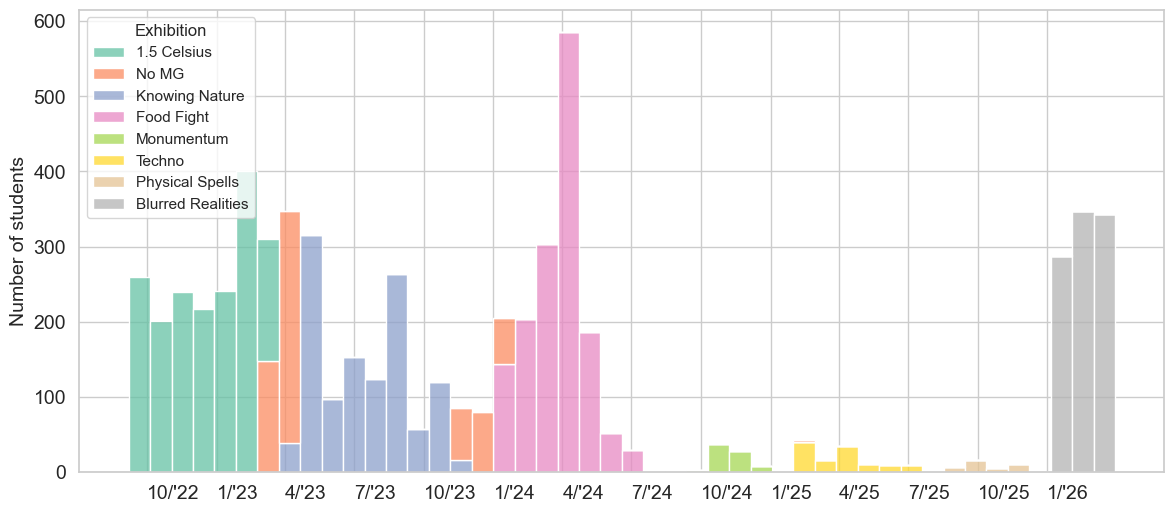

In [29]:
#x_dates = pd.date_range(start='2022-09-01', end='2024-07-01', freq='QS', inclusive='both')
x_dates = pd.date_range(start='2022-09-01', end='2026-03-31', freq='QS', inclusive='both')
#print(x_dates)

fig, ax = plt.subplots(figsize=(14,6))
fig = sns.histplot(data=df_s, x='DateTime', hue='Exhibition', weights="Quantity", bins=46, multiple='stack', 
                   palette="Set2",)
ax.set_xticks(x_dates, labels=x_dates.strftime("%-m/'%y"), horizontalalignment='left')
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_xlabel("")
ax.set_ylabel("Number of students")
ax.xaxis.label.set_size(14)
ax.yaxis.label.set_size(14)
fig.figure.savefig("student_timeline.png",bbox_inches='tight')
plt.show()

/var/folders/56/pmp8wp79205_qtsg828g7bdc0000gq/T/ipykernel_83620/4203590275.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(hour_labels)


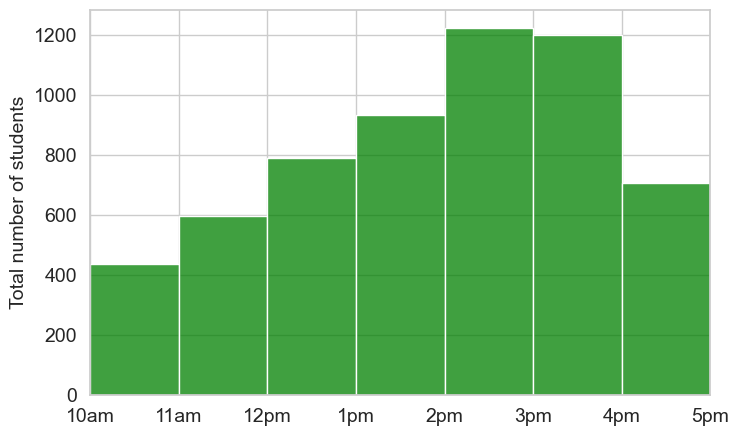

In [30]:
hours=(1000,1100,1200,1300,1400,1500,1600,1700)
hour_labels=("10am","11am","12pm","1pm","2pm","3pm","4pm","5pm")
fig, ax = plt.subplots(figsize=(8,5))
fig = sns.histplot(data=df_s, x='NumTime', weights='Quantity', bins=hours, color='green')
ax.set_xlim(1000, 1700)
ax.set_xticklabels(hour_labels)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_xlabel("")
ax.set_ylabel("Total number of students")
ax.xaxis.label.set_size(14)
ax.yaxis.label.set_size(14)
fig.figure.savefig("student_time_bar.png", bbox_inches='tight')
plt.show()

/var/folders/56/pmp8wp79205_qtsg828g7bdc0000gq/T/ipykernel_83620/1817431589.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  fig.set_xticklabels(fig.get_xticklabels())


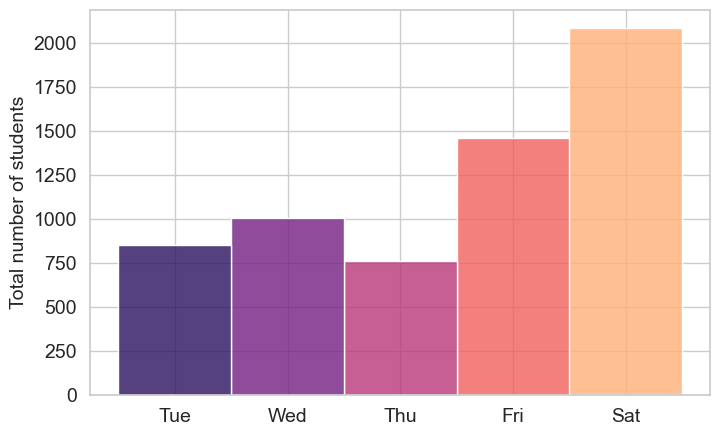

In [31]:
fig, ax = plt.subplots(figsize=(8,5))
fig = sns.histplot(df_s, x='Day', hue='Day', weights='Quantity', palette='magma', alpha=0.8, legend=False)
fig.set_xticklabels(fig.get_xticklabels())
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_xlabel("")
ax.set_ylabel("Total number of students")
ax.xaxis.label.set_size(14)
ax.yaxis.label.set_size(14)
fig.figure.savefig("student_day_bar.png", bbox_inches='tight')
plt.show()

/var/folders/56/pmp8wp79205_qtsg828g7bdc0000gq/T/ipykernel_83620/3264785102.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  fig.set_xticklabels(fig.get_xticklabels(), rotation=345)
/var/folders/56/pmp8wp79205_qtsg828g7bdc0000gq/T/ipykernel_83620/3264785102.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(hour_labels)


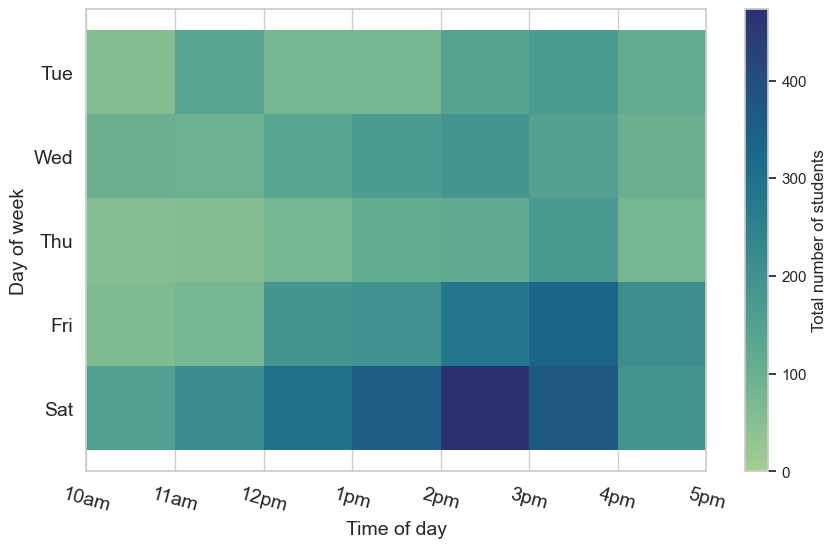

In [32]:
fig, ax = plt.subplots(figsize=(10,6))
fig = sns.histplot(df_s, x='NumTime', y='Day', weights='Quantity', bins=hours, 
                   cmap='crest', cbar=True, cbar_kws={'label':'Total number of students'})
fig.set_xticklabels(fig.get_xticklabels(), rotation=345)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_xlim(1000, 1700)
ax.set_xticklabels(hour_labels)
ax.set_xlabel("Time of day")
ax.set_ylabel("Day of week")
ax.xaxis.label.set_size(14)
ax.yaxis.label.set_size(14)
fig.figure.savefig("student_daytime_2D.png", bbox_inches='tight')
plt.show()